In [15]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [16]:
from google.colab import drive
drive.mount('/content/drive')

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Prodigy infotech/Hand gesture'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
print("✅ Dataset Loaded Successfully")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Prodigy infotech/Hand gesture/amer_sign2.png
/content/drive/MyDrive/Prodigy infotech/Hand gesture/amer_sign3.png
/content/drive/MyDrive/Prodigy infotech/Hand gesture/american_sign_language.PNG
/content/drive/MyDrive/Prodigy infotech/Hand gesture/sign_mnist_test.csv
/content/drive/MyDrive/Prodigy infotech/Hand gesture/sign_mnist_train.csv
/content/drive/MyDrive/Prodigy infotech/Hand gesture/sign_mnist_train/sign_mnist_train.csv
/content/drive/MyDrive/Prodigy infotech/Hand gesture/sign_mnist_test/sign_mnist_test.csv
✅ Dataset Loaded Successfully


In [17]:
# Load CSV
train_df = pd.read_csv("/content/drive/MyDrive/Prodigy infotech/Hand gesture/sign_mnist_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Prodigy infotech/Hand gesture/sign_mnist_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# Extract X and y
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values

X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Normalize and reshape
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


Train shape: (27455, 785)
Test shape: (7172, 785)


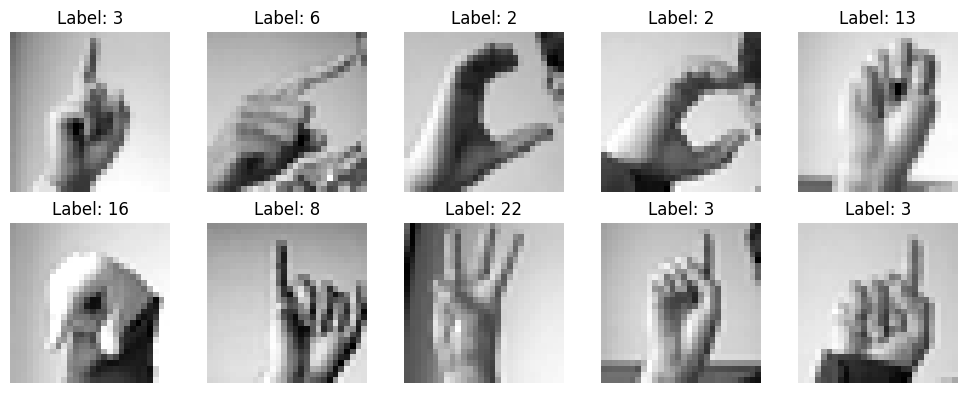

In [18]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [19]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,969 (886.60 KB)

 Trainable params: 226,969 (886.60 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=64
)


Epoch 1/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 31s 66ms/step - accuracy: 0.2808 - loss: 2.4118 - val_accuracy: 0.8081 - val_loss: 0.6385
Epoch 2/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 40s 64ms/step - accuracy: 0.7987 - loss: 0.6091 - val_accuracy: 0.8917 - val_loss: 0.3346
Epoch 3/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 39s 59ms/step - accuracy: 0.9020 - loss: 0.2973 - val_accuracy: 0.9279 - val_loss: 0.2556
Epoch 4/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.9453 - loss: 0.1731 - val_accuracy: 0.9129 - val_loss: 0.2956
Epoch 5/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - accuracy: 0.9615 - loss: 0.1232 - val_accuracy: 0.9283 - val_loss: 0.2697
Epoch 6/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 42s 65ms/step - accuracy: 0.9689 - loss: 0.0940 - val_accuracy: 0.9373 - val_loss: 0.2602
Epoch 7/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.9754 - loss: 0.0723 - val_accuracy: 0.9286 - val_loss: 0.2608
Epoch 8/10
429/429 ━━━━━━━━━━━━━━━━━━━━ 28s 66ms/step - accuracy: 0.9790 - loss: 0.0634 - 

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9397 - loss: 0.3021
✅ Test Accuracy: 94.12%


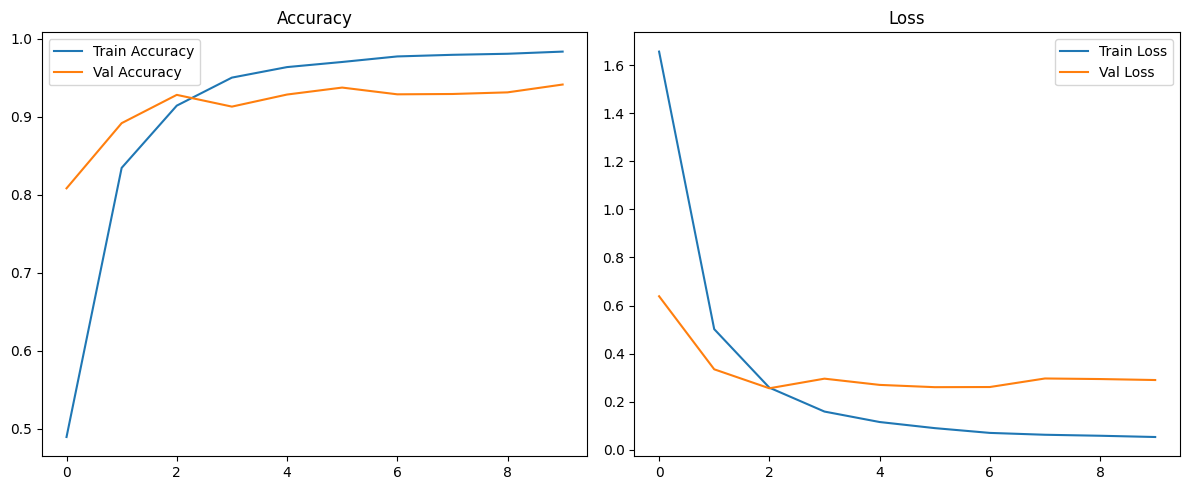

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"✅ Test Accuracy: {accuracy * 100:.2f}%")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.tight_layout()
plt.show()
